# 02 Polar Verity Sense Offline Runbook

## A. Setup

In [12]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import pandas as pd

NOTEBOOK_ROOT = Path.cwd()
LIB_ROOT = NOTEBOOK_ROOT / "lib"
if str(LIB_ROOT) not in sys.path:
    sys.path.insert(0, str(LIB_ROOT))

from session_discovery import list_sessions
from remote_sync import get_session_by_id
from pipeline_client import run_full_pipeline
from session_loader import load_summary, load_clean, load_window_features, load_raw_chunks
from eda_helpers import compute_gap_stats, ensure_datetime, pick_first_column

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 220)

In [ ]:
# Runtime parameters
user_id = 1
session_id_override = "d49ff28f-38e2-4a8b-9c94-03643edf68c9"  # set specific session id if needed
user_id_candidates = [1, 2]  # fallback search when session_id_override is set
max_rows_per_stream = 100000
env_path = NOTEBOOK_ROOT / ".env"
plot_points = 4000
live_progress = False  # avoid SSH progress polling loop issues

## B. Session Discovery

In [14]:
sessions = list_sessions(user_id=user_id, env_path=env_path)
offline_sessions = [s for s in sessions if str(s.get("source","")).lower() == "polar_verity_sense" and str(s.get("collection_mode","")).lower() == "offline_recording"]
print(f"discovered={len(sessions)} offline_verity={len(offline_sessions)}")
pd.DataFrame(offline_sessions).head(20)

discovered=0 offline_verity=0


""


In [15]:
if session_id_override:
    # Resolve correct user_id for explicit session_id override.
    matched_user_id = None
    for candidate_user_id in user_id_candidates:
        try:
            candidate_sessions = list_sessions(user_id=candidate_user_id, env_path=env_path)
        except Exception:
            continue
        if any(str(item.get("session_id")) == str(session_id_override) for item in candidate_sessions):
            matched_user_id = candidate_user_id
            break

    if matched_user_id is not None:
        user_id = matched_user_id
    session_id = session_id_override
elif offline_sessions:
    session_id = str(offline_sessions[0]["session_id"])
else:
    raise RuntimeError("No Polar Verity Sense offline sessions found. Set session_id_override.")

print("user_id:", user_id)
print("session_id:", session_id)


user_id: 1
session_id: 20a3ce5a-37a0-465f-8b92-87b951485948


## C. Run Pipeline

In [16]:
pipeline_result = run_full_pipeline(
    session_id=session_id,
    user_id=user_id,
    env_path=env_path,
    live_progress=False,
)
pipeline_result

Final step summary:
[normalize] status=success streams: success=6 skipped=0 failed=0
[window_features] status=success streams: success=6 skipped=0 failed=0
[build_session_summary] status=partial streams: success=6 skipped=0 failed=0


{'response': {'sessions_discovered': 1,
  'normalize_runs': [{'run_id': '7afb203e34904ed0a03b4f7ea202b61d',
    'status': 'success',
    'session_id': '20a3ce5a-37a0-465f-8b92-87b951485948',
    'step_name': 'normalize',
    'state_path': '/data/wearable/pipeline_runs/normalize/7afb203e34904ed0a03b4f7ea202b61d.json',
    'discovered_streams': ['acc', 'gyro', 'hr', 'mag', 'ppg', 'ppi'],
    'per_stream_results': [{'stream_type': 'acc',
      'handler_name': 'PolarVerityOfflineNormalizer',
      'status': 'success',
      'input_path': '/data/wearable/raw/user_id=2/source=polar_verity_sense/date=2026-05-05/session_id=20a3ce5a-37a0-465f-8b92-87b951485948/streams/acc/chunks.jsonl',
      'output_path': '/data/wearable/processed/clean_timeseries/user_id=2/source=polar_verity_sense/session_id=20a3ce5a-37a0-465f-8b92-87b951485948/streams/acc/data.parquet',
      'error': None},
     {'stream_type': 'gyro',
      'handler_name': 'PolarVerityOfflineNormalizer',
      'status': 'success',
      

## D. Sync Data

In [17]:
session_cache_path = get_session_by_id(session_id=session_id, env_path=env_path)
print(session_cache_path)

notebooks/data_cache/session_id=20a3ce5a-37a0-465f-8b92-87b951485948


import json
## E. Load Artifacts

In [18]:
summary = load_summary(session_cache_path)
clean = load_clean(session_cache_path, max_rows_per_stream=max_rows_per_stream)
window_features = load_window_features(session_cache_path, max_rows_per_stream=max_rows_per_stream)
raw = load_raw_chunks(session_cache_path, preview_rows_per_stream=20, max_scan_lines_per_stream=5000)

print("clean streams:", sorted(clean.keys()))
print("window streams:", sorted(window_features.keys()))
print("raw streams:", sorted(raw.keys()))
summary.get("_source_path")

clean streams: ['acc', 'gyro', 'hr', 'mag', 'ppg', 'ppi']
window streams: ['acc', 'gyro', 'hr', 'mag', 'ppg', 'ppi']
raw streams: ['acc', 'gyro', 'hr', 'mag', 'ppg', 'ppi']


'notebooks/data_cache/session_id=20a3ce5a-37a0-465f-8b92-87b951485948/data/wearable/processed/window_features/user_id=2/source=polar_verity_sense/session_id=20a3ce5a-37a0-465f-8b92-87b951485948/session_summary.json'

## F. Time Alignment Reports

In [19]:
report_paths = sorted(Path(session_cache_path).glob("**/processed/clean_timeseries/**/time_alignment_report.json"))
reports = []
for p in report_paths:
    payload = json.loads(p.read_text(encoding="utf-8"))
    payload["_path"] = str(p)
    reports.append(payload)

report_df = pd.DataFrame([
    {
        "stream_type": r.get("stream_type"),
        "alignment_basis_level": r.get("alignment_basis_level") or "legacy",
        "alignment_basis": r.get("alignment_basis"),
        "alignment_basis_details": (r.get("alignment_basis_details") or {}).get("selected_reason") if isinstance(r.get("alignment_basis_details"), dict) else r.get("epoch_offset_decision"),
        "confidence": r.get("confidence"),
        "applied_shift_ns": r.get("applied_shift_ns"),
        "samples_count": r.get("samples_count"),
        "session_window_start": r.get("session_window_start") or (r.get("normalized_time_range") or {}).get("start_utc"),
        "session_window_end": r.get("session_window_end") or (r.get("normalized_time_range") or {}).get("end_utc"),
        "per_stream_start": r.get("per_stream_start") or (r.get("normalized_time_range") or {}).get("start_utc"),
        "per_stream_end": r.get("per_stream_end") or (r.get("normalized_time_range") or {}).get("end_utc"),
        "hard_fail_reasons": "; ".join(r.get("hard_fail_reasons") or []),
        "warnings": "; ".join(r.get("warnings") or []),
        "path": r.get("_path"),
    }
    for r in reports
])
report_df.sort_values(["stream_type"]).reset_index(drop=True) if not report_df.empty else report_df


,stream_type,alignment_basis_level,alignment_basis,alignment_basis_details,confidence,applied_shift_ns,samples_count,session_window_start,session_window_end,per_stream_start,per_stream_end,hard_fail_reasons,warnings,path
0,acc,L0,recording_start_utc/recording_end_utc,device_recording_metadata,high,-610650000,2060,2026-05-05T11:43:28.999999344Z,2026-05-05T11:45:01.804534102Z,2026-05-05T11:43:28.999999344Z,2026-05-05T11:45:01.804534102Z,,duration deviates from expected cadence,notebooks/data_cache/session_id=20a3ce5a-37a0-...
1,gyro,L0,recording_start_utc/recording_end_utc,device_recording_metadata,high,-1778225000,2080,2026-05-05T11:43:28.999999896Z,2026-05-05T11:45:01.813000750Z,2026-05-05T11:43:28.999999896Z,2026-05-05T11:45:01.813000750Z,,duration deviates from expected cadence,notebooks/data_cache/session_id=20a3ce5a-37a0-...
2,hr,L0,recording_start_utc/recording_end_utc,device_recording_metadata,high,0,49,2026-05-05T11:43:16Z,2026-05-05T11:44:31Z,2026-05-05T11:43:16Z,2026-05-05T11:44:31Z,,duration deviates from expected cadence,notebooks/data_cache/session_id=20a3ce5a-37a0-...
3,mag,L0,recording_start_utc/recording_end_utc,device_recording_metadata,high,-1377088000,2424,2026-05-05T11:43:28.999999232Z,2026-05-05T11:45:04.246270334Z,2026-05-05T11:43:28.999999232Z,2026-05-05T11:45:04.246270334Z,,duration deviates from expected cadence,notebooks/data_cache/session_id=20a3ce5a-37a0-...
4,ppg,L0,recording_start_utc/recording_end_utc,device_recording_metadata,high,-2825631000,2440,2026-05-05T11:43:28.999999208Z,2026-05-05T11:45:03.647806224Z,2026-05-05T11:43:28.999999208Z,2026-05-05T11:45:03.647806224Z,,duration deviates from expected cadence,notebooks/data_cache/session_id=20a3ce5a-37a0-...
5,ppi,L0,recording_start_utc/recording_end_utc,device_recording_metadata,medium,0,24,2026-05-05T11:44:31Z,2026-05-05T11:44:54Z,2026-05-05T11:44:31Z,2026-05-05T11:44:54Z,,ppi invalid_or_zero_timestamps fallback used f...,notebooks/data_cache/session_id=20a3ce5a-37a0-...


## G. Stream Quality Checks

In [20]:
rows=[]
for stream, df in clean.items():
    local, ts_col = ensure_datetime(df)
    if ts_col is None or local.empty:
        rows.append({"stream":stream,"rows":len(df.index),"ts_col":ts_col,"duration_s":None,"median_delta_s":None,"max_delta_s":None,"duplicates":None})
        continue
    gaps = compute_gap_stats(local[ts_col])
    duration = (local[ts_col].max() - local[ts_col].min()).total_seconds() if len(local.index)>1 else 0
    rows.append({
        "stream":stream,
        "rows":len(local.index),
        "ts_col":ts_col,
        "duration_s":float(duration),
        "median_delta_s":gaps.median_delta_seconds,
        "max_delta_s":gaps.max_delta_seconds,
        "duplicates":gaps.duplicate_timestamps,
    })

pd.DataFrame(rows).sort_values("stream")

,stream,rows,ts_col,duration_s,median_delta_s,max_delta_s,duplicates
0,acc,2060,ts_utc,92.804534,0.01960,48.559639,0
1,gyro,2080,ts_utc,92.813000,0.01960,48.164988,0
2,hr,49,ts_utc,75.000000,1.00000,30.000000,2
3,mag,2424,ts_utc,95.246271,0.02036,46.019259,0
4,ppg,2440,ts_utc,94.647807,0.01823,46.099559,0
5,ppi,24,ts_utc,23.000000,1.00000,1.000000,0


## H. Stream Tables And Plots


### acc ###


,ts_utc,received_at_collector,uploaded_at_collector,received_at_server,session_id,stream_id,stream_type,payload_schema,user_id,source_vendor,source_device_model,source_device_id,collection_mode,source_chunk_id,source_sequence,source_line_number,alignment_confidence,raw_sample_timestamp_ns,sample_index,vector_magnitude,x,y,z
0,2026-05-05 11:43:28.999999344+00:00,2026-05-05T11:43:51.898Z,2026-05-05T11:43:54.709Z,2026-05-05T11:43:54.812246Z,20a3ce5a-37a0-465f-8b92-87b951485948,stream-offline-acc-20a3ce5a-37a0-465f-8b92-87b...,acc,polar.offline.acc,2,polar,verity_sense,B15B5829,offline_recording,fcfe1bf7-3820-4507-8b0d-b0a8f8c76df7,1,1,high,831296609610649344,0,986.530790,153.0,-675.0,-703.0
1,2026-05-05 11:43:29.019230064+00:00,2026-05-05T11:43:51.898Z,2026-05-05T11:43:54.709Z,2026-05-05T11:43:54.812246Z,20a3ce5a-37a0-465f-8b92-87b951485948,stream-offline-acc-20a3ce5a-37a0-465f-8b92-87b...,acc,polar.offline.acc,2,polar,verity_sense,B15B5829,offline_recording,fcfe1bf7-3820-4507-8b0d-b0a8f8c76df7,1,1,high,831296609629880064,1,986.056286,159.0,-675.0,-701.0
2,2026-05-05 11:43:29.038460912+00:00,2026-05-05T11:43:51.898Z,2026-05-05T11:43:54.709Z,2026-05-05T11:43:54.812246Z,20a3ce5a-37a0-465f-8b92-87b951485948,stream-offline-acc-20a3ce5a-37a0-465f-8b92-87b...,acc,polar.offline.acc,2,polar,verity_sense,B15B5829,offline_recording,fcfe1bf7-3820-4507-8b0d-b0a8f8c76df7,1,1,high,831296609649110912,2,987.091688,161.0,-675.0,-702.0
3,2026-05-05 11:43:29.057691632+00:00,2026-05-05T11:43:51.898Z,2026-05-05T11:43:54.709Z,2026-05-05T11:43:54.812246Z,20a3ce5a-37a0-465f-8b92-87b951485948,stream-offline-acc-20a3ce5a-37a0-465f-8b92-87b...,acc,polar.offline.acc,2,polar,verity_sense,B15B5829,offline_recording,fcfe1bf7-3820-4507-8b0d-b0a8f8c76df7,1,1,high,831296609668341632,3,987.054710,160.0,-671.0,-706.0
4,2026-05-05 11:43:29.076922480+00:00,2026-05-05T11:43:51.898Z,2026-05-05T11:43:54.709Z,2026-05-05T11:43:54.812246Z,20a3ce5a-37a0-465f-8b92-87b951485948,stream-offline-acc-20a3ce5a-37a0-465f-8b92-87b...,acc,polar.offline.acc,2,polar,verity_sense,B15B5829,offline_recording,fcfe1bf7-3820-4507-8b0d-b0a8f8c76df7,1,1,high,831296609687572480,4,985.592715,160.0,-672.0,-703.0
5,2026-05-05 11:43:29.096153200+00:00,2026-05-05T11:43:51.898Z,2026-05-05T11:43:54.709Z,2026-05-05T11:43:54.812246Z,20a3ce5a-37a0-465f-8b92-87b951485948,stream-offline-acc-20a3ce5a-37a0-465f-8b92-87b...,acc,polar.offline.acc,2,polar,verity_sense,B15B5829,offline_recording,fcfe1bf7-3820-4507-8b0d-b0a8f8c76df7,1,1,high,831296609706803200,5,989.297225,153.0,-678.0,-704.0
6,2026-05-05 11:43:29.115383920+00:00,2026-05-05T11:43:51.898Z,2026-05-05T11:43:54.709Z,2026-05-05T11:43:54.812246Z,20a3ce5a-37a0-465f-8b92-87b951485948,stream-offline-acc-20a3ce5a-37a0-465f-8b92-87b...,acc,polar.offline.acc,2,polar,verity_sense,B15B5829,offline_recording,fcfe1bf7-3820-4507-8b0d-b0a8f8c76df7,1,1,high,831296609726033920,6,984.451116,158.0,-676.0,-698.0
7,2026-05-05 11:43:29.134614768+00:00,2026-05-05T11:43:51.898Z,2026-05-05T11:43:54.709Z,2026-05-05T11:43:54.812246Z,20a3ce5a-37a0-465f-8b92-87b951485948,stream-offline-acc-20a3ce5a-37a0-465f-8b92-87b...,acc,polar.offline.acc,2,polar,verity_sense,B15B5829,offline_recording,fcfe1bf7-3820-4507-8b0d-b0a8f8c76df7,1,1,high,831296609745264768,7,991.294608,157.0,-680.0,-704.0
8,2026-05-05 11:43:29.153845488+00:00,2026-05-05T11:43:51.898Z,2026-05-05T11:43:54.709Z,2026-05-05T11:43:54.812246Z,20a3ce5a-37a0-465f-8b92-87b951485948,stream-offline-acc-20a3ce5a-37a0-465f-8b92-87b...,acc,polar.offline.acc,2,polar,verity_sense,B15B5829,offline_recording,fcfe1bf7-3820-4507-8b0d-b0a8f8c76df7,1,1,high,831296609764495488,8,989.347765,158.0,-679.0,-702.0
9,2026-05-05 11:43:29.173076208+00:00,2026-05-05T11:43:51.898Z,2026-05-05T11:43:54.709Z,2026-05-05T11:43:54.812246Z,20a3ce5a-37a0-465f-8b92-87b951485948,stream-offline-acc-20a3ce5a-37a0-465f-8b92-87b...,acc,polar.offline.acc,2,polar,verity_sense,B15B5829,offline_recording,fcfe1bf7-3820-4507-8b0d-b0a8f8c76df7,1,1,high,8312966097837262

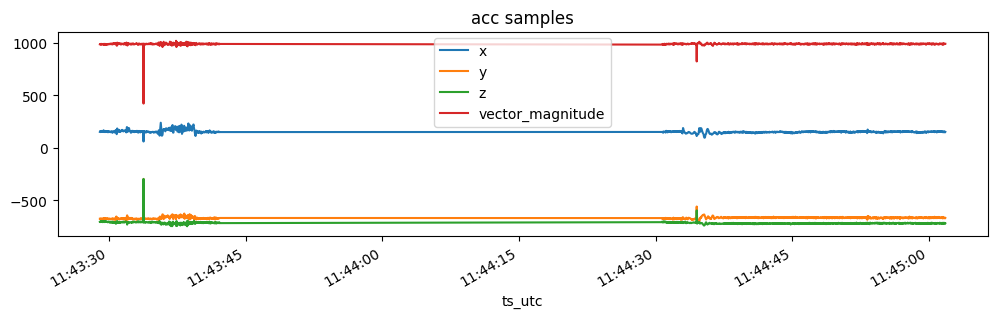


### gyro ###


,ts_utc,received_at_collector,uploaded_at_collector,received_at_server,session_id,stream_id,stream_type,payload_schema,user_id,source_vendor,source_device_model,source_device_id,collection_mode,source_chunk_id,source_sequence,source_line_number,alignment_confidence,raw_sample_timestamp_ns,sample_index,vector_magnitude,x,y,z
0,2026-05-05 11:43:28.999999896+00:00,2026-05-05T11:43:51.898Z,2026-05-05T11:43:54.920Z,2026-05-05T11:43:54.952029Z,20a3ce5a-37a0-465f-8b92-87b951485948,stream-offline-gyro-20a3ce5a-37a0-465f-8b92-87...,gyro,polar.offline.gyro,2,polar,verity_sense,B15B5829,offline_recording,f1bbb2e8-1318-42ef-9741-a321c499b7ad,1,1,high,831296610778224896,0,1.486573,-1.47,0.21,-0.07
1,2026-05-05 11:43:29.019230616+00:00,2026-05-05T11:43:51.898Z,2026-05-05T11:43:54.920Z,2026-05-05T11:43:54.952029Z,20a3ce5a-37a0-465f-8b92-87b951485948,stream-offline-gyro-20a3ce5a-37a0-465f-8b92-87...,gyro,polar.offline.gyro,2,polar,verity_sense,B15B5829,offline_recording,f1bbb2e8-1318-42ef-9741-a321c499b7ad,1,1,high,831296610797455616,1,1.391222,-1.33,0.35,-0.21
2,2026-05-05 11:43:29.038461464+00:00,2026-05-05T11:43:51.898Z,2026-05-05T11:43:54.920Z,2026-05-05T11:43:54.952029Z,20a3ce5a-37a0-465f-8b92-87b951485948,stream-offline-gyro-20a3ce5a-37a0-465f-8b92-87...,gyro,polar.offline.gyro,2,polar,verity_sense,B15B5829,offline_recording,f1bbb2e8-1318-42ef-9741-a321c499b7ad,1,1,high,831296610816686464,2,1.587010,-1.33,0.84,-0.21
3,2026-05-05 11:43:29.057692184+00:00,2026-05-05T11:43:51.898Z,2026-05-05T11:43:54.920Z,2026-05-05T11:43:54.952029Z,20a3ce5a-37a0-465f-8b92-87b951485948,stream-offline-gyro-20a3ce5a-37a0-465f-8b92-87...,gyro,polar.offline.gyro,2,polar,verity_sense,B15B5829,offline_recording,f1bbb2e8-1318-42ef-9741-a321c499b7ad,1,1,high,831296610835917184,3,1.597780,-1.26,0.98,-0.07
4,2026-05-05 11:43:29.076923032+00:00,2026-05-05T11:43:51.898Z,2026-05-05T11:43:54.920Z,2026-05-05T11:43:54.952029Z,20a3ce5a-37a0-465f-8b92-87b951485948,stream-offline-gyro-20a3ce5a-37a0-465f-8b92-87...,gyro,polar.offline.gyro,2,polar,verity_sense,B15B5829,offline_recording,f1bbb2e8-1318-42ef-9741-a321c499b7ad,1,1,high,831296610855148032,4,1.596246,-1.26,0.98,0.00
5,2026-05-05 11:43:29.096153752+00:00,2026-05-05T11:43:51.898Z,2026-05-05T11:43:54.920Z,2026-05-05T11:43:54.952029Z,20a3ce5a-37a0-465f-8b92-87b951485948,stream-offline-gyro-20a3ce5a-37a0-465f-8b92-87...,gyro,polar.offline.gyro,2,polar,verity_sense,B15B5829,offline_recording,f1bbb2e8-1318-42ef-9741-a321c499b7ad,1,1,high,831296610874378752,5,1.698853,-1.47,0.84,-0.14
6,2026-05-05 11:43:29.115384472+00:00,2026-05-05T11:43:51.898Z,2026-05-05T11:43:54.920Z,2026-05-05T11:43:54.952029Z,20a3ce5a-37a0-465f-8b92-87b951485948,stream-offline-gyro-20a3ce5a-37a0-465f-8b92-87...,gyro,polar.offline.gyro,2,polar,verity_sense,B15B5829,offline_recording,f1bbb2e8-1318-42ef-9741-a321c499b7ad,1,1,high,831296610893609472,6,1.734532,-1.54,0.63,-0.49
7,2026-05-05 11:43:29.134615320+00:00,2026-05-05T11:43:51.898Z,2026-05-05T11:43:54.920Z,2026-05-05T11:43:54.952029Z,20a3ce5a-37a0-465f-8b92-87b951485948,stream-offline-gyro-20a3ce5a-37a0-465f-8b92-87...,gyro,polar.offline.gyro,2,polar,verity_sense,B15B5829,offline_recording,f1bbb2e8-1318-42ef-9741-a321c499b7ad,1,1,high,831296610912840320,7,1.528823,-1.26,0.84,-0.21
8,2026-05-05 11:43:29.153846040+00:00,2026-05-05T11:43:51.898Z,2026-05-05T11:43:54.920Z,2026-05-05T11:43:54.952029Z,20a3ce5a-37a0-465f-8b92-87b951485948,stream-offline-gyro-20a3ce5a-37a0-465f-8b92-87...,gyro,polar.offline.gyro,2,polar,verity_sense,B15B5829,offline_recording,f1bbb2e8-1318-42ef-9741-a321c499b7ad,1,1,high,831296610932071040,8,1.634166,-1.40,0.84,-0.07
9,2026-05-05 11:43:29.173076760+00:00,2026-05-05T11:43:51.898Z,2026-05-05T11:43:54.920Z,2026-05-05T11:43:54.952029Z,20a3ce5a-37a0-465f-8b92-87b951485948,stream-offline-gyro-20a3ce5a-37a0-465f-8b92-87...,gyro,polar.offline.gyro,2,polar,verity_sense,B15B5829,offline_recording,f1bbb2e8-1318-42ef-9741-a321c499b7ad,1,1,high,831296610951301760,9,1.981136,-1.89,0.42,-

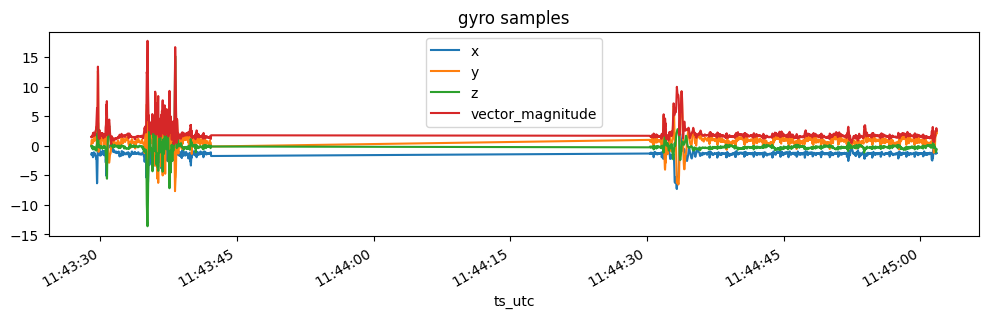


### hr ###


,ts_utc,received_at_collector,uploaded_at_collector,received_at_server,session_id,stream_id,stream_type,payload_schema,user_id,source_vendor,source_device_model,source_device_id,collection_mode,source_chunk_id,source_sequence,source_line_number,alignment_confidence,contact_status,contact_status_supported,corrected_hr,hr,ppg_quality,raw_sample_timestamp_ns,rr_available,rrs_ms,sample_index
0,2026-05-05 11:43:16+00:00,2026-05-05T11:43:51.898Z,2026-05-05T11:43:53.793Z,2026-05-05T11:43:54.694899Z,20a3ce5a-37a0-465f-8b92-87b951485948,stream-offline-hr-20a3ce5a-37a0-465f-8b92-87b9...,hr,polar.offline.hr,2,polar,verity_sense,B15B5829,offline_recording,dc84d7d6-0520-4f9b-bfcb-2192eb604bbf,1,1,high,False,False,0,69,0,None,False,[],1
1,2026-05-05 11:43:17+00:00,2026-05-05T11:43:51.898Z,2026-05-05T11:43:53.793Z,2026-05-05T11:43:54.694899Z,20a3ce5a-37a0-465f-8b92-87b951485948,stream-offline-hr-20a3ce5a-37a0-465f-8b92-87b9...,hr,polar.offline.hr,2,polar,verity_sense,B15B5829,offline_recording,dc84d7d6-0520-4f9b-bfcb-2192eb604bbf,1,1,high,False,False,0,69,0,None,False,[],2
2,2026-05-05 11:43:18+00:00,2026-05-05T11:43:51.898Z,2026-05-05T11:43:53.793Z,2026-05-05T11:43:54.694899Z,20a3ce5a-37a0-465f-8b92-87b951485948,stream-offline-hr-20a3ce5a-37a0-465f-8b92-87b9...,hr,polar.offline.hr,2,polar,verity_sense,B15B5829,offline_recording,dc84d7d6-0520-4f9b-bfcb-2192eb604bbf,1,1,high,False,False,0,69,0,None,False,[],3
3,2026-05-05 11:43:19+00:00,2026-05-05T11:43:51.898Z,2026-05-05T11:43:53.793Z,2026-05-05T11:43:54.694899Z,20a3ce5a-37a0-465f-8b92-87b951485948,stream-offline-hr-20a3ce5a-37a0-465f-8b92-87b9...,hr,polar.offline.hr,2,polar,verity_sense,B15B5829,offline_recording,dc84d7d6-0520-4f9b-bfcb-2192eb604bbf,1,1,high,False,False,0,70,0,None,False,[],4
4,2026-05-05 11:43:20+00:00,2026-05-05T11:43:51.898Z,2026-05-05T11:43:53.793Z,2026-05-05T11:43:54.694899Z,20a3ce5a-37a0-465f-8b92-87b951485948,stream-offline-hr-20a3ce5a-37a0-465f-8b92-87b9...,hr,polar.offline.hr,2,polar,verity_sense,B15B5829,offline_recording,dc84d7d6-0520-4f9b-bfcb-2192eb604bbf,1,1,high,False,False,0,0,0,None,False,[],5
5,2026-05-05 11:43:21+00:00,2026-05-05T11:43:51.898Z,2026-05-05T11:43:53.793Z,2026-05-05T11:43:54.694899Z,20a3ce5a-37a0-465f-8b92-87b951485948,stream-offline-hr-20a3ce5a-37a0-465f-8b92-87b9...,hr,polar.offline.hr,2,polar,verity_sense,B15B5829,offline_recording,dc84d7d6-0520-4f9b-bfcb-2192eb604bbf,1,1,high,False,False,0,0,0,None,False,[],6
6,2026-05-05 11:43:22+00:00,2026-05-05T11:43:51.898Z,2026-05-05T11:43:53.793Z,2026-05-05T11:43:54.694899Z,20a3ce5a-37a0-465f-8b92-87b951485948,stream-offline-hr-20a3ce5a-37a0-465f-8b92-87b9...,hr,polar.offline.hr,2,polar,verity_sense,B15B5829,offline_recording,dc84d7d6-0520-4f9b-bfcb-2192eb604bbf,1,1,high,False,False,0,0,0,None,False,[],7
7,2026-05-05 11:43:23+00:00,2026-05-05T11:43:51.898Z,2026-05-05T11:43:53.793Z,2026-05-05T11:43:54.694899Z,20a3ce5a-37a0-465f-8b92-87b951485948,stream-offline-hr-20a3ce5a-37a0-465f-8b92-87b9...,hr,polar.offline.hr,2,polar,verity_sense,B15B5829,offline_recording,dc84d7d6-0520-4f9b-bfcb-2192eb604bbf,1,1,high,False,False,0,0,0,None,False,[],8
8,2026-05-05 11:43:24+00:00,2026-05-05T11:43:51.898Z,2026-05-05T11:43:53.793Z,2026-05-05T11:43:54.694899Z,20a3ce5a-37a0-465f-8b92-87b951485948,stream-offline-hr-20a3ce5a-37a0-465f-8b92-87b9...,hr,polar.offline.hr,2,polar,verity_sense,B15B5829,offline_recording,dc84d7d6-0520-4f9b-bfcb-2192eb604bbf,1,1,high,False,False,0,0,0,None,False,[],9
9,2026-05-05 11:43:25+00:00,2026-05-05T11:43:51.898Z,2026-05-05T11:43:53.793Z,2026-05-05T11:43:54.694899Z,20a3ce5a-37a0-465f-8b92-87b951485948,stream-offline-hr-20a3ce5a-37a0-465f-8b92-87b9...,hr,polar.offline.hr,2,polar,verity_sense,B15B5829,offline_recording,dc84d7d6-0520-4f9b-bfcb-2192eb604bbf,1,1,high,False,False,0,0,0,None,False,[],10


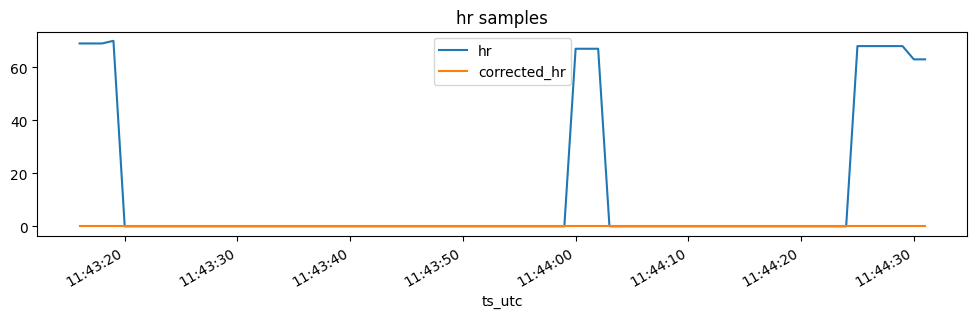


### mag ###


,ts_utc,received_at_collector,uploaded_at_collector,received_at_server,session_id,stream_id,stream_type,payload_schema,user_id,source_vendor,source_device_model,source_device_id,collection_mode,source_chunk_id,source_sequence,source_line_number,alignment_confidence,raw_sample_timestamp_ns,sample_index,vector_magnitude,x,y,z
0,2026-05-05 11:43:28.999999232+00:00,2026-05-05T11:43:51.898Z,2026-05-05T11:43:54.874Z,2026-05-05T11:43:54.909646Z,20a3ce5a-37a0-465f-8b92-87b951485948,stream-offline-mag-20a3ce5a-37a0-465f-8b92-87b...,mag,polar.offline.mag,2,polar,verity_sense,B15B5829,offline_recording,edab0d2c-ff82-4ae6-a6f4-b959db66d934,1,1,high,831296610377087232,0,1.086117,-0.3930,-0.7755,0.6510
1,2026-05-05 11:43:29.019999232+00:00,2026-05-05T11:43:51.898Z,2026-05-05T11:43:54.874Z,2026-05-05T11:43:54.909646Z,20a3ce5a-37a0-465f-8b92-87b951485948,stream-offline-mag-20a3ce5a-37a0-465f-8b92-87b...,mag,polar.offline.mag,2,polar,verity_sense,B15B5829,offline_recording,edab0d2c-ff82-4ae6-a6f4-b959db66d934,1,1,high,831296610397087232,1,1.083238,-0.3900,-0.7755,0.6480
2,2026-05-05 11:43:29.039999232+00:00,2026-05-05T11:43:51.898Z,2026-05-05T11:43:54.874Z,2026-05-05T11:43:54.909646Z,20a3ce5a-37a0-465f-8b92-87b951485948,stream-offline-mag-20a3ce5a-37a0-465f-8b92-87b...,mag,polar.offline.mag,2,polar,verity_sense,B15B5829,offline_recording,edab0d2c-ff82-4ae6-a6f4-b959db66d934,1,1,high,831296610417087232,2,1.079681,-0.3795,-0.7770,0.6465
3,2026-05-05 11:43:29.059999232+00:00,2026-05-05T11:43:51.898Z,2026-05-05T11:43:54.874Z,2026-05-05T11:43:54.909646Z,20a3ce5a-37a0-465f-8b92-87b951485948,stream-offline-mag-20a3ce5a-37a0-465f-8b92-87b...,mag,polar.offline.mag,2,polar,verity_sense,B15B5829,offline_recording,edab0d2c-ff82-4ae6-a6f4-b959db66d934,1,1,high,831296610437087232,3,1.083060,-0.3885,-0.7785,0.6450
4,2026-05-05 11:43:29.079999232+00:00,2026-05-05T11:43:51.898Z,2026-05-05T11:43:54.874Z,2026-05-05T11:43:54.909646Z,20a3ce5a-37a0-465f-8b92-87b951485948,stream-offline-mag-20a3ce5a-37a0-465f-8b92-87b...,mag,polar.offline.mag,2,polar,verity_sense,B15B5829,offline_recording,edab0d2c-ff82-4ae6-a6f4-b959db66d934,1,1,high,831296610457087232,4,1.085927,-0.3915,-0.7785,0.6480
5,2026-05-05 11:43:29.099999232+00:00,2026-05-05T11:43:51.898Z,2026-05-05T11:43:54.874Z,2026-05-05T11:43:54.909646Z,20a3ce5a-37a0-465f-8b92-87b951485948,stream-offline-mag-20a3ce5a-37a0-465f-8b92-87b...,mag,polar.offline.mag,2,polar,verity_sense,B15B5829,offline_recording,edab0d2c-ff82-4ae6-a6f4-b959db66d934,1,1,high,831296610477087232,5,1.079498,-0.3810,-0.7785,0.6435
6,2026-05-05 11:43:29.119999232+00:00,2026-05-05T11:43:51.898Z,2026-05-05T11:43:54.874Z,2026-05-05T11:43:54.909646Z,20a3ce5a-37a0-465f-8b92-87b951485948,stream-offline-mag-20a3ce5a-37a0-465f-8b92-87b...,mag,polar.offline.mag,2,polar,verity_sense,B15B5829,offline_recording,edab0d2c-ff82-4ae6-a6f4-b959db66d934,1,1,high,831296610497087232,6,1.074186,-0.3720,-0.7755,0.6435
7,2026-05-05 11:43:29.139999232+00:00,2026-05-05T11:43:51.898Z,2026-05-05T11:43:54.874Z,2026-05-05T11:43:54.909646Z,20a3ce5a-37a0-465f-8b92-87b951485948,stream-offline-mag-20a3ce5a-37a0-465f-8b92-87b...,mag,polar.offline.mag,2,polar,verity_sense,B15B5829,offline_recording,edab0d2c-ff82-4ae6-a6f4-b959db66d934,1,1,high,831296610517087232,7,1.078489,-0.3750,-0.7725,0.6525
8,2026-05-05 11:43:29.159999232+00:00,2026-05-05T11:43:51.898Z,2026-05-05T11:43:54.874Z,2026-05-05T11:43:54.909646Z,20a3ce5a-37a0-465f-8b92-87b951485948,stream-offline-mag-20a3ce5a-37a0-465f-8b92-87b...,mag,polar.offline.mag,2,polar,verity_sense,B15B5829,offline_recording,edab0d2c-ff82-4ae6-a6f4-b959db66d934,1,1,high,831296610537087232,8,1.084328,-0.3855,-0.7755,0.6525
9,2026-05-05 11:43:29.179999232+00:00,2026-05-05T11:43:51.898Z,2026-05-05T11:43:54.874Z,2026-05-05T11:43:54.909646Z,20a3ce5a-37a0-465f-8b92-87b951485948,stream-offline-mag-20a3ce5a-37a0-465f-8b92-87b...,mag,polar.offline.mag,2,polar,verity_sense,B15B5829,offline_recording,edab0d2c-ff82-4ae6-a6f4-b959db66d934,1,1,high,8312966

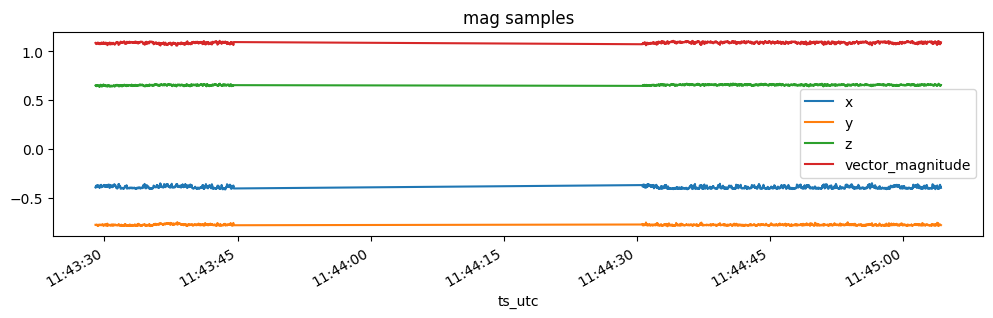


### ppg ###


,ts_utc,received_at_collector,uploaded_at_collector,received_at_server,session_id,stream_id,stream_type,payload_schema,user_id,source_vendor,source_device_model,source_device_id,collection_mode,source_chunk_id,source_sequence,source_line_number,alignment_confidence,ambient,channel_samples,ppg0,ppg1,ppg2,raw_sample_timestamp_ns,sample_index
0,2026-05-05 11:43:28.999999208+00:00,2026-05-05T11:43:51.898Z,2026-05-05T11:43:54.815Z,2026-05-05T11:43:54.873294Z,20a3ce5a-37a0-465f-8b92-87b951485948,stream-offline-ppg-20a3ce5a-37a0-465f-8b92-87b...,ppg,polar.offline.ppg,2,polar,verity_sense,B15B5829,offline_recording,811de5e6-605c-43db-997d-b2186c82ff06,1,1,high,174488,"[426972, 505483, 489904, 174488]",426972,505483,489904,831296611825630208,0
1,2026-05-05 11:43:29.018180968+00:00,2026-05-05T11:43:51.898Z,2026-05-05T11:43:54.815Z,2026-05-05T11:43:54.873294Z,20a3ce5a-37a0-465f-8b92-87b951485948,stream-offline-ppg-20a3ce5a-37a0-465f-8b92-87b...,ppg,polar.offline.ppg,2,polar,verity_sense,B15B5829,offline_recording,811de5e6-605c-43db-997d-b2186c82ff06,1,1,high,174544,"[426503, 504669, 489252, 174544]",426503,504669,489252,831296611843811968,1
2,2026-05-05 11:43:29.036362856+00:00,2026-05-05T11:43:51.898Z,2026-05-05T11:43:54.815Z,2026-05-05T11:43:54.873294Z,20a3ce5a-37a0-465f-8b92-87b951485948,stream-offline-ppg-20a3ce5a-37a0-465f-8b92-87b...,ppg,polar.offline.ppg,2,polar,verity_sense,B15B5829,offline_recording,811de5e6-605c-43db-997d-b2186c82ff06,1,1,high,174510,"[425943, 504015, 488648, 174510]",425943,504015,488648,831296611861993856,2
3,2026-05-05 11:43:29.054544616+00:00,2026-05-05T11:43:51.898Z,2026-05-05T11:43:54.815Z,2026-05-05T11:43:54.873294Z,20a3ce5a-37a0-465f-8b92-87b951485948,stream-offline-ppg-20a3ce5a-37a0-465f-8b92-87b...,ppg,polar.offline.ppg,2,polar,verity_sense,B15B5829,offline_recording,811de5e6-605c-43db-997d-b2186c82ff06,1,1,high,174540,"[425714, 503590, 488209, 174540]",425714,503590,488209,831296611880175616,3
4,2026-05-05 11:43:29.072726504+00:00,2026-05-05T11:43:51.898Z,2026-05-05T11:43:54.815Z,2026-05-05T11:43:54.873294Z,20a3ce5a-37a0-465f-8b92-87b951485948,stream-offline-ppg-20a3ce5a-37a0-465f-8b92-87b...,ppg,polar.offline.ppg,2,polar,verity_sense,B15B5829,offline_recording,811de5e6-605c-43db-997d-b2186c82ff06,1,1,high,174505,"[425403, 503144, 487858, 174505]",425403,503144,487858,831296611898357504,4
5,2026-05-05 11:43:29.090908264+00:00,2026-05-05T11:43:51.898Z,2026-05-05T11:43:54.815Z,2026-05-05T11:43:54.873294Z,20a3ce5a-37a0-465f-8b92-87b951485948,stream-offline-ppg-20a3ce5a-37a0-465f-8b92-87b...,ppg,polar.offline.ppg,2,polar,verity_sense,B15B5829,offline_recording,811de5e6-605c-43db-997d-b2186c82ff06,1,1,high,174518,"[425244, 502994, 487763, 174518]",425244,502994,487763,831296611916539264,5
6,2026-05-05 11:43:29.109090152+00:00,2026-05-05T11:43:51.898Z,2026-05-05T11:43:54.815Z,2026-05-05T11:43:54.873294Z,20a3ce5a-37a0-465f-8b92-87b951485948,stream-offline-ppg-20a3ce5a-37a0-465f-8b92-87b...,ppg,polar.offline.ppg,2,polar,verity_sense,B15B5829,offline_recording,811de5e6-605c-43db-997d-b2186c82ff06,1,1,high,174495,"[425144, 502832, 487634, 174495]",425144,502832,487634,831296611934721152,6
7,2026-05-05 11:43:29.127271912+00:00,2026-05-05T11:43:51.898Z,2026-05-05T11:43:54.815Z,2026-05-05T11:43:54.873294Z,20a3ce5a-37a0-465f-8b92-87b951485948,stream-offline-ppg-20a3ce5a-37a0-465f-8b92-87b...,ppg,polar.offline.ppg,2,polar,verity_sense,B15B5829,offline_recording,811de5e6-605c-43db-997d-b2186c82ff06,1,1,high,174498,"[425123, 502811, 487636, 174498]",425123,502811,487636,831296611952902912,7
8,2026-05-05 11:43:29.145453800+00:00,2026-05-05T11:43:51.898Z,2026-05-05T11:43:54.815Z,2026-05-05T11:43:54.873294Z,20a3ce5a-37a0-465f-8b92-87b951485948,stream-offline-ppg-20a3ce5a-37a0-465f-8b92-87b...,ppg,polar.offline.ppg,2,polar,verity_sense,B15B5829,offline_recording,811de5e6-605c-43db-997d-b2186c82ff06,1,1,high,174508,"[425260, 502893, 487735, 174508]",425260,502893,487735,831296611971084800,8
9,2026-05-05 11:43:29.163635560

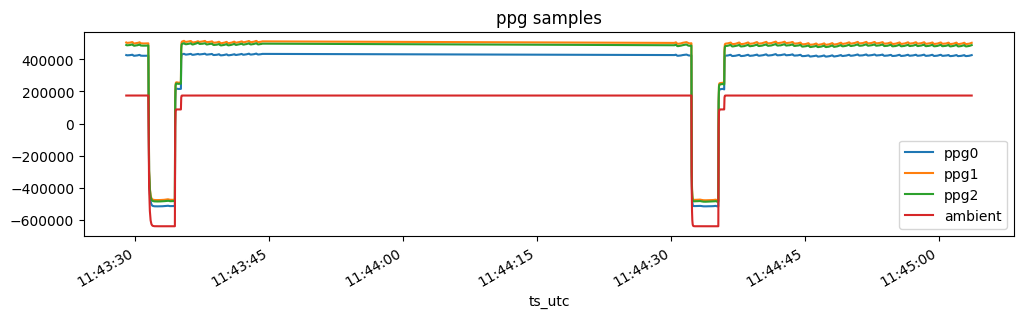


### ppi ###


,ts_utc,received_at_collector,uploaded_at_collector,received_at_server,session_id,stream_id,stream_type,payload_schema,user_id,source_vendor,source_device_model,source_device_id,collection_mode,source_chunk_id,source_sequence,source_line_number,alignment_confidence,blocker_bit,hr,pp_error_estimate,pp_in_ms,raw_sample_timestamp_ns,sample_index,skin_contact_status,skin_contact_supported
0,2026-05-05 11:44:31+00:00,2026-05-05T11:45:11.167Z,2026-05-05T11:45:15.005Z,2026-05-05T11:45:15.026169Z,20a3ce5a-37a0-465f-8b92-87b951485948,stream-offline-ppi-20a3ce5a-37a0-465f-8b92-87b...,ppi,polar.offline.ppi,2,polar,verity_sense,B15B5829,offline_recording,cadac839-1f4f-477d-8cb5-192b3017102a,1,1,high,1,0,30,389,0,0,1,1
1,2026-05-05 11:44:32+00:00,2026-05-05T11:45:11.167Z,2026-05-05T11:45:15.005Z,2026-05-05T11:45:15.026169Z,20a3ce5a-37a0-465f-8b92-87b951485948,stream-offline-ppi-20a3ce5a-37a0-465f-8b92-87b...,ppi,polar.offline.ppi,2,polar,verity_sense,B15B5829,offline_recording,cadac839-1f4f-477d-8cb5-192b3017102a,1,1,high,1,0,30,1166,0,1,1,1
2,2026-05-05 11:44:33+00:00,2026-05-05T11:45:11.167Z,2026-05-05T11:45:15.005Z,2026-05-05T11:45:15.026169Z,20a3ce5a-37a0-465f-8b92-87b951485948,stream-offline-ppi-20a3ce5a-37a0-465f-8b92-87b...,ppi,polar.offline.ppi,2,polar,verity_sense,B15B5829,offline_recording,cadac839-1f4f-477d-8cb5-192b3017102a,1,1,high,0,0,30,1050,0,2,1,1
3,2026-05-05 11:44:34+00:00,2026-05-05T11:45:11.167Z,2026-05-05T11:45:15.005Z,2026-05-05T11:45:15.026169Z,20a3ce5a-37a0-465f-8b92-87b951485948,stream-offline-ppi-20a3ce5a-37a0-465f-8b92-87b...,ppi,polar.offline.ppi,2,polar,verity_sense,B15B5829,offline_recording,cadac839-1f4f-477d-8cb5-192b3017102a,1,1,high,0,0,30,997,0,3,1,1
4,2026-05-05 11:44:35+00:00,2026-05-05T11:45:11.167Z,2026-05-05T11:45:15.005Z,2026-05-05T11:45:15.026169Z,20a3ce5a-37a0-465f-8b92-87b951485948,stream-offline-ppi-20a3ce5a-37a0-465f-8b92-87b...,ppi,polar.offline.ppi,2,polar,verity_sense,B15B5829,offline_recording,cadac839-1f4f-477d-8cb5-192b3017102a,1,1,high,0,0,30,995,0,4,1,1
5,2026-05-05 11:44:36+00:00,2026-05-05T11:45:11.167Z,2026-05-05T11:45:15.005Z,2026-05-05T11:45:15.026169Z,20a3ce5a-37a0-465f-8b92-87b951485948,stream-offline-ppi-20a3ce5a-37a0-465f-8b92-87b...,ppi,polar.offline.ppi,2,polar,verity_sense,B15B5829,offline_recording,cadac839-1f4f-477d-8cb5-192b3017102a,1,1,high,0,0,30,989,0,5,1,1
6,2026-05-05 11:44:37+00:00,2026-05-05T11:45:11.167Z,2026-05-05T11:45:15.005Z,2026-05-05T11:45:15.026169Z,20a3ce5a-37a0-465f-8b92-87b951485948,stream-offline-ppi-20a3ce5a-37a0-465f-8b92-87b...,ppi,polar.offline.ppi,2,polar,verity_sense,B15B5829,offline_recording,cadac839-1f4f-477d-8cb5-192b3017102a,1,1,high,0,0,30,1038,0,6,1,1
7,2026-05-05 11:44:38+00:00,2026-05-05T11:45:11.167Z,2026-05-05T11:45:15.005Z,2026-05-05T11:45:15.026169Z,20a3ce5a-37a0-465f-8b92-87b951485948,stream-offline-ppi-20a3ce5a-37a0-465f-8b92-87b...,ppi,polar.offline.ppi,2,polar,verity_sense,B15B5829,offline_recording,cadac839-1f4f-477d-8cb5-192b3017102a,1,1,high,0,0,30,1067,0,7,1,1
8,2026-05-05 11:44:39+00:00,2026-05-05T11:45:11.167Z,2026-05-05T11:45:15.005Z,2026-05-05T11:45:15.026169Z,20a3ce5a-37a0-465f-8b92-87b951485948,stream-offline-ppi-20a3ce5a-37a0-465f-8b92-87b...,ppi,polar.offline.ppi,2,polar,verity_sense,B15B5829,offline_recording,cadac839-1f4f-477d-8cb5-192b3017102a,1,1,high,0,68,26,979,0,8,1,1
9,2026-05-05 11:44:40+00:00,2026-05-05T11:45:11.167Z,2026-05-05T11:45:15.005Z,2026-05-05T11:45:15.026169Z,20a3ce5a-37a0-465f-8b92-87b951485948,stream-offline-ppi-20a3ce5a-37a0-465f-8b92-87b...,ppi,polar.offline.ppi,2,polar,verity_sense,B15B5829,offline_recording,cadac839-1f4f-477d-8cb5-192b3017102a,1,1,high,0,68,21,904,0,9,1,1


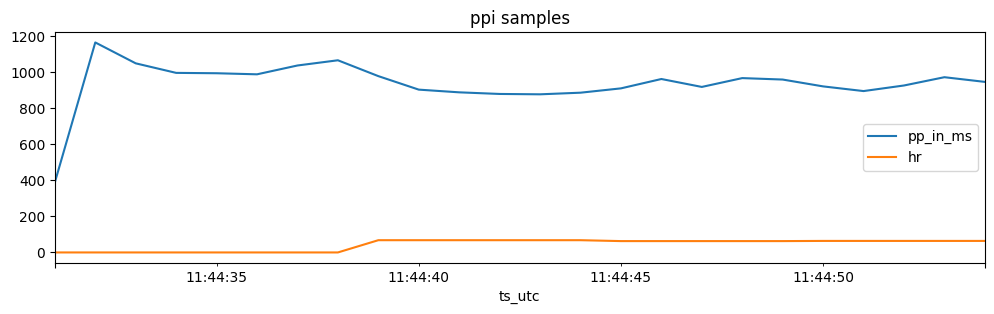

In [21]:
plot_columns = {
    "hr": ["hr", "corrected_hr"],
    "ppi": ["pp_in_ms", "hr"],
    "acc": ["x", "y", "z", "vector_magnitude"],
    "gyro": ["x", "y", "z", "vector_magnitude"],
    "mag": ["x", "y", "z", "vector_magnitude"],
    "ppg": ["ppg0", "ppg1", "ppg2", "ambient"],
}
for stream, df in sorted(clean.items()):
    print(f"\n### {stream} ###")
    if df.empty:
        print("empty")
        continue
    local, ts_col = ensure_datetime(df)
    display(local.head(10))
    if ts_col is None:
        print("no timestamp column")
        continue
    cols = [c for c in plot_columns.get(stream, []) if c in local.columns]
    if not cols:
        print("no plot columns")
        continue
    sampled = local if len(local.index) <= plot_points else local.iloc[::max(1, len(local.index)//plot_points)].copy()
    ax = sampled.plot(x=ts_col, y=cols, figsize=(12, 3), title=f"{stream} samples")
    ax.set_xlabel("ts_utc")
    plt.show()

## I. Session Summary Snapshot

In [22]:
if summary:
    print("status:", summary.get("status"))
    print("streams_present:", summary.get("streams_present"))
    print("streams_missing:", summary.get("streams_missing"))
    display(pd.DataFrame(summary.get("stream_summaries", {})).T[["status","warnings"]])
else:
    print("summary missing")

status: partial
streams_present: ['hr', 'acc', 'ppi', 'gyro', 'mag', 'ppg']
streams_missing: ['ecg', 'battery']


,status,warnings
hr,success,[]
acc,success,[]
ecg,missing,[empty dataset]
battery,missing,[empty dataset]
ppi,success,[]
gyro,success,[]
mag,success,[]
ppg,success,[]
